Claro. Esta parte corresponde al Ejemplo 8 de PyKAN: Continual Learning. La idea de los autores es mostrar que una KAN puede aprender una función por etapas sin olvidar tanto lo que aprendió antes. En el ejemplo oficial, la función 1D tiene 5 picos gaussianos y la red ve los datos en 5 fases, una región por vez. Los autores lo relacionan con la localidad de las splines: al ajustar una zona local de la función, no necesariamente se modifican todas las demás zonas.

¿Qué significa aprendizaje continuo?

El aprendizaje continuo o continual learning se refiere a entrenar un modelo con información que llega de manera secuencial, no toda al mismo tiempo.

Por ejemplo, en vez de darle a la red todos los datos de una vez:

D=D_1∪D_2∪D_3∪D_4∪D_5
	​

se le presentan por etapas:

D1→D2→D3→D4→D5
	​

El problema clásico es el olvido catastrófico:

Cuando el modelo aprende una tarea nueva, puede olvidar lo que aprendió en tareas anteriores.

En este ejemplo, cada pico gaussiano puede verse como una “tarea” o una “fase” del aprendizaje.

La KAN primero aprende el pico 1, luego el pico 2, luego el pico 3, etc. Lo interesante es observar si al aprender el pico nuevo conserva los picos anteriores.

¿Por qué las KAN pueden ayudar aquí?

En una MLP clásica, los pesos suelen afectar globalmente a la función aprendida. Si modificas los pesos para aprender una nueva región, puedes alterar mucho lo aprendido antes.

En cambio, en una KAN las conexiones son funciones aprendibles, normalmente representadas con splines. Las splines tienen una propiedad importante: son locales.

Eso significa que cambiar la spline en una región del eje x afecta principalmente esa región, no necesariamente todo el dominio.

Por eso, los autores dicen que las KAN pueden ayudar en aprendizaje continuo gracias a la localidad de las splines.

In [1]:
from kan import *
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
datasets = []

n_peak = 5
n_num_per_peak = 100
n_sample = n_peak * n_num_per_peak

In [3]:
x_grid = torch.linspace(-1,1,steps=n_sample)

x_centers = 2/n_peak * (np.arange(n_peak) - n_peak/2+0.5)

x_sample = torch.stack([torch.linspace(-1/n_peak,1/n_peak,steps=n_num_per_peak)+center for center in x_centers]).reshape(-1,)


In [4]:
y = 0.
for center in x_centers:
    y += torch.exp(-(x_grid-center)**2*300)

y_sample = 0.
for center in x_centers:
    y_sample += torch.exp(-(x_sample-center)**2*300)


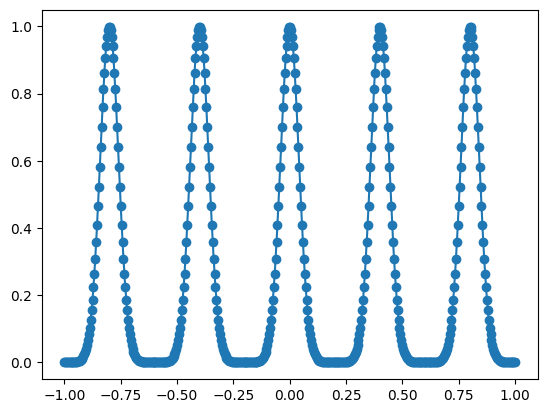

In [5]:
plt.plot(x_grid.detach().numpy(), y.detach().numpy())
plt.scatter(x_sample.detach().numpy(), y_sample.detach().numpy())

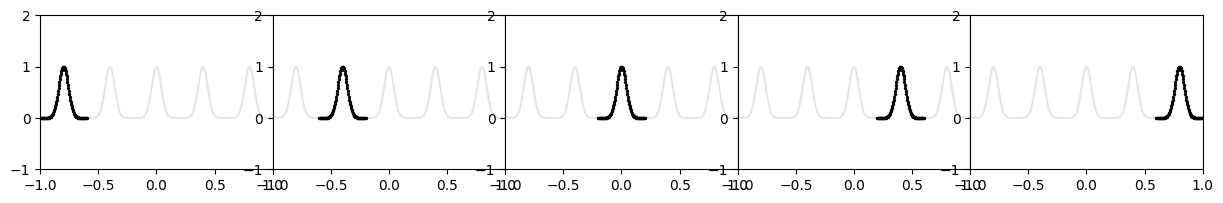

In [6]:
plt.subplots(1, 5, figsize=(15, 2))
plt.subplots_adjust(wspace=0, hspace=0)

for i in range(1,6):
    plt.subplot(1,5,i)
    group_id = i - 1
    plt.plot(x_grid.detach().numpy(), y.detach().numpy(), color='black', alpha=0.1)
    plt.scatter(x_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak].detach().numpy(), y_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak].detach().numpy(), color="black", s=2)
    plt.xlim(-1,1)
    plt.ylim(-1,2)

In [19]:
ys = []

# setting bias_trainable=False, sp_trainable=False, sb_trainable=False is important.
# otherwise KAN will have random scaling and shift for samples in previous stages

#model = KAN(width=[1,1], grid=200, k=3, noise_scale=0.1, sp_trainable=False, sb_trainable=False, base_fun='zero')
model = KAN(width=[1,1], grid=200, k=3, noise_scale=10, sp_trainable=False, sb_trainable=False, base_fun='zero')

for group_id in range(n_peak):
    dataset = {}
    dataset['train_input'] = x_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak][:,None]
    dataset['train_label'] = y_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak][:,None]
    dataset['test_input'] = x_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak][:,None]
    dataset['test_label'] = y_sample[group_id*n_num_per_peak:(group_id+1)*n_num_per_peak][:,None]
    model.fit(dataset, opt = 'LBFGS', steps=100, update_grid=False)
    #model.plot()
    y_pred = model(x_grid[:,None])
    ys.append(y_pred.detach().numpy()[:,0])

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

| train_loss: 3.99e-06 | test_loss: 3.99e-06 | reg: 3.31e+00 | : 100%|█| 100/100 [00:00<00:00, 175.6


saving model version 0.1


| train_loss: 3.99e-06 | test_loss: 3.99e-06 | reg: 3.31e+00 | : 100%|█| 100/100 [00:00<00:00, 204.7


...

saving model version 0.3


| train_loss: 3.99e-06 | test_loss: 3.99e-06 | reg: 3.31e+00 | : 100%|█| 100/100 [00:00<00:00, 138.8


saving model version 0.4


| train_loss: 3.99e-06 | test_loss: 3.99e-06 | reg: 3.31e+00 | : 100%|█| 100/100 [00:00<00:00, 176.6


saving model version 0.5


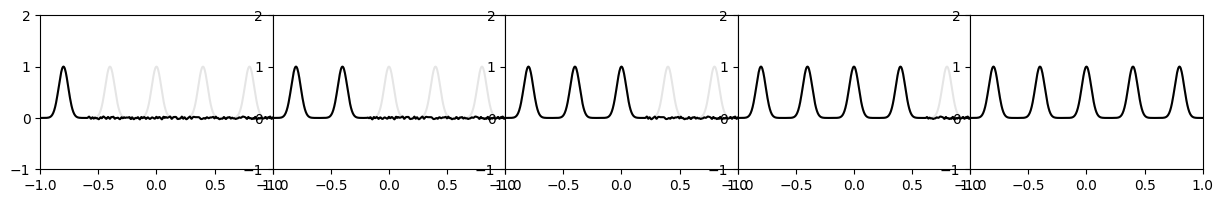

In [20]:
plt.subplots(1, 5, figsize=(15, 2))
plt.subplots_adjust(wspace=0, hspace=0)

for i in range(1,6):
    plt.subplot(1,5,i)
    group_id = i - 1
    plt.plot(x_grid.detach().numpy(), y.detach().numpy(), color='black', alpha=0.1)
    plt.plot(x_grid.detach().numpy(), ys[i-1], color='black')
    plt.xlim(-1,1)
    plt.ylim(-1,2)

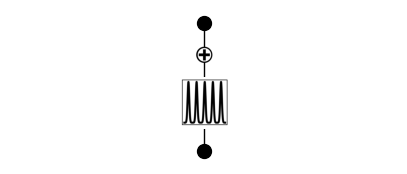

In [21]:
model.plot()

In [39]:
x = torch.rand(3, 6) * 2 - 1

batch = x.shape[0]
x[:,2] = torch.exp(torch.sin(torch.pi*x[:,0])+x[:,1]**2)
x[:,3] = x[:,4]**3

In [40]:
y = copy.deepcopy(x)
for i in range(y.shape[1]):
    y[:,i] = y[:,i][torch.randperm(y.shape[0])]

In [41]:
print(x)
print(y)

tensor([[ 0.6967,  0.2871,  2.4536,  0.3239,  0.6868, -0.1773],
        [-0.4375,  0.3150,  0.4141,  0.0163,  0.2536, -0.4330],
        [-0.8015,  0.5413,  0.7476,  0.0026,  0.1367, -0.5820]])
tensor([[-0.8015,  0.2871,  2.4536,  0.0026,  0.6868, -0.5820],
        [ 0.6967,  0.5413,  0.4141,  0.3239,  0.1367, -0.1773],
        [-0.4375,  0.3150,  0.7476,  0.0163,  0.2536, -0.4330]])


In [20]:
from kan import KAN
import torch
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

seed = 2024

model = KAN(width=[6,1,1], grid=3, k=3, seed=seed, device=device)

# create dataset


def create_dataset(train_num=500, test_num=500):

    def generate_contrastive(x):
        # positive samples
        batch = x.shape[0]
        x[:,2] = torch.exp(torch.sin(torch.pi*x[:,0])+x[:,1]**2)
        x[:,3] = x[:,4]**3

        # negative samples
        def corrupt(tensor):
            y = copy.deepcopy(tensor)
            for i in range(y.shape[1]):
                y[:,i] = y[:,i][torch.randperm(y.shape[0])]
            return y

        x_cor = corrupt(x)
        x = torch.cat([x, x_cor], dim=0)
        y = torch.cat([torch.ones(batch,), torch.zeros(batch,)], dim=0)[:,None]
        return x, y

    x = torch.rand(train_num, 6) * 2 - 1
    x_train, y_train = generate_contrastive(x)

    x = torch.rand(test_num, 6) * 2 - 1
    x_test, y_test = generate_contrastive(x)

    dataset = {}
    dataset['train_input'] = x_train.to(device)
    dataset['test_input'] = x_test.to(device)
    dataset['train_label'] = y_train.to(device)
    dataset['test_label'] = y_test.to(device)
    return dataset

dataset = create_dataset()

cpu
checkpoint directory created: ./model
saving model version 0.0


In [22]:
model(dataset['train_input'])
#model.plot(beta=10)
dataset['train_input']

tensor([[-1.1881e-01,  1.2924e-01,  7.0614e-01,  1.9651e-03,  1.2526e-01,
         -9.0623e-01],
        [-9.6097e-02, -8.2418e-02,  7.4786e-01,  2.4725e-05,  2.9132e-02,
         -9.5147e-02],
        [ 9.4018e-01, -5.3146e-01,  1.5988e+00, -2.1629e-01, -6.0027e-01,
         -4.6322e-01],
        ...,
        [-3.7165e-01, -8.7609e-01,  2.0385e+00, -4.2697e-01,  3.5807e-01,
          4.1396e-01],
        [ 7.3254e-01,  9.1411e-01,  9.0873e-01, -1.4387e-03,  4.6290e-01,
         -8.3111e-01],
        [-5.0520e-01,  4.0388e-01,  1.9018e+00,  1.4227e-02,  9.7169e-02,
          6.8978e-01]])

In [23]:
# set the (1,0,0) activation to be gausssian
#model.fix_symbolic(1,0,0,lambda x: torch.exp(-x**2/10),fit_params_bool=False)
model.fix_symbolic(1,0,0,'gaussian',fit_params_bool=False)

saving model version 0.1


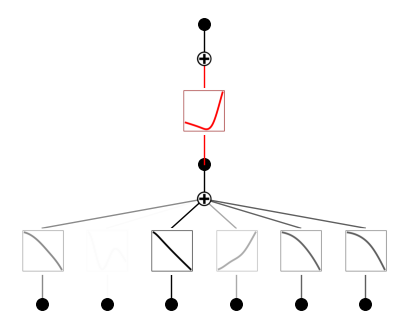

In [24]:
model.plot()

In [25]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.002, lamb_entropy=10.0, lamb_coef=1.0)

| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 1.13e+00 | : 100%|█| 50/50 [00:03<00:00, 14.92it

saving model version 0.2


{'train_loss': [array(0.49951982, dtype=float32),
  array(0.5000008, dtype=float32),
  array(0.5000012, dtype=float32),
  array(0.50000095, dtype=float32),
  array(0.5000003, dtype=float32),
  array(0.5000003, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.49999997, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=float32),
  array(0.49999997, dtype=float32),
  array(0.5, dtype=float32),
  array(0.5, dtype=fl

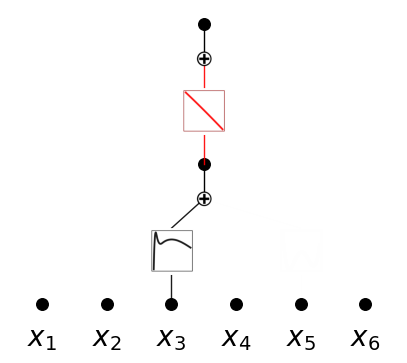

In [26]:
model.plot(in_vars=[r'$x_{}$'.format(i) for i in range(1,7)])